In [16]:
import numpy as np
import sympy as sym
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint


In [17]:
# Energy density of φ:

# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = var(r'κ') # k = sqrt(8πG)
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')

# b) Define V function and its derivative
V = function('V')(phi)
V = (M^(4+alp))/phi^alp
show(V)
dVdφ  = V.diff(phi)
show(dVdφ)

M^(α + 4)/φ^α

-M^(α + 4)*α*φ^(α - 1)/φ^(2*α)

In [18]:
# 2. Change φ in dVdΦ to φ(Ν)
N = var('N')
Phi = function(r'Φ')(N)
dvdΦ = dVdφ.subs(phi == Phi)

In [19]:
# Constants used 
ohm_m = 0.31
k = sqrt(8*np.pi) # κ = 8πG In reduced Planck Units
alp = 2
Ho = 67.7 # in km/s/Mpc
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
Pm = var(r'P_m')

In [22]:
# Klein Gordon Equation w.r.t N as two first order equations

def solveSteinhardtKG(X,N):
    '''Expressions'''
    a = exp(N) # N = ln(a)
    rho_m = rho_c0*ohm_m*a^(-3)
    V = (M^(4+alp))/X[0]^alp
    x1prime = X[1]
    x2prime = (1-(Pm + rho_m)/2*(V + rho_m))*(k^2/2 * (X[1])^3-3*X[1]) + (alp/X[0])*V
    return [x1prime,x2prime]

In [23]:
dPhi = Phi.diff(N)
X = [Phi,dPhi]
show(X)
show(solveSteinhardtKG(X,N))

[Φ(N), diff(Φ(N), N)]

[diff(Φ(N), N),
 2*M^6/Φ(N)^3 - 1/2*(12.56637061435917*diff(Φ(N), N)^3 - 3*diff(Φ(N), N))*((M^6/Φ(N)^2 + 169.597882746249*e^(-3*N))*(P_m + 169.597882746249*e^(-3*N)) - 2)]

In [25]:
N_range = np.arange(-1.1,5.1,0.1)
def orders(N_values):
    sol = odeint(solveSteinhardtKG,[1,0],N_values)
    return sol
    #sol = odeint(solveKG(X,exp(N),gam=1,V0=V0,k=sqrt(8*np.pi),lam=0.5),[1,0],N_range)
    #solve_ivp(solveKG(X,gam,a,V0,k,lam),[N_range[0],N_range[-1]],(3))
solutions = orders(N_range)
#show(solutions)

TypeError: unable to simplify to float approximation

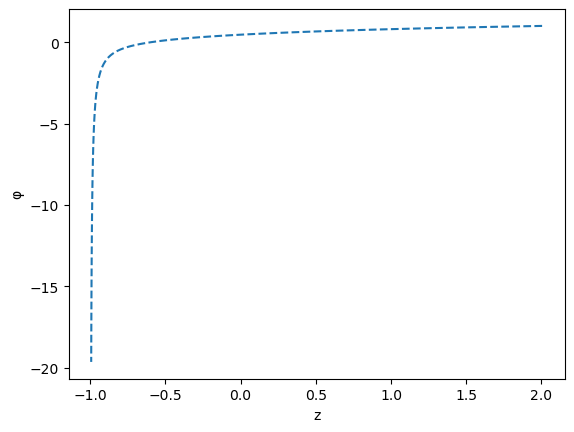

In [72]:
# Plot of φ against redshift
phi_sol = solutions[:,0]
phi_prime = solutions[:,1]

z_values = exp(-N_range)-1
plt.xlabel("z")
plt.ylabel(r"φ")
plt.plot(z_values,phi_sol,'--')

In [73]:
# Other Cosmological parameters that use Phi and dPhi

def other_parameters(phi,dphi,N):
    a = exp(-N)
    z = 1/a -1
    V0 = rho_c0
    V = V0*exp(-lam*k*phi)
    H_2 = (k^2)*(V + rho_c0*ohm_m*a^(-3))/(3-k^2/2*(dphi)^2) + V

    rho_φ = 0.5*(dphi^2*H_2) - V #Energy density of φ (ρ_φ)
    O_φ = k^2/3*rho_φ/H_2 # Ωφ
    Pφ = 0.5*(dphi^2*H_2) + V
    w = Pφ/rho_φ #Equation of State wΦ
    return z,rho_φ,O_φ,w
    
z,rho,om,w = other_parameters(phi_sol,phi_prime,N_range)

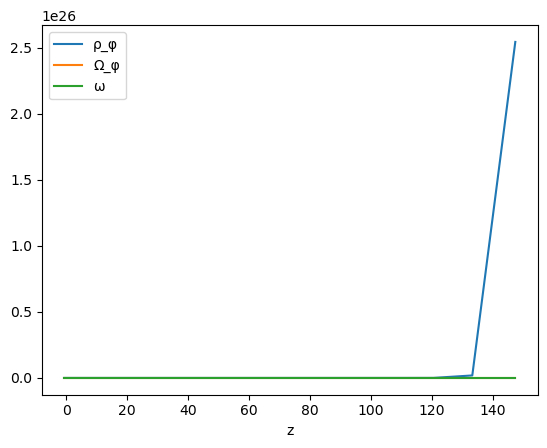

In [74]:
# Plots of energy density, 
plt.plot(z,rho,label=r"ρ_φ")
plt.plot(z,om,label=r"Ω_φ") # something wrong as it shouldn't be zero
plt.plot(z,w,label=r"ω") # interestingly -1 for all z
plt.xlabel("z")
plt.legend()


In [ ]:


# def solveKG(X,a,gam,V0,k,lam):
#     ohm_m = 0.31
    
#     Ho = 
#     rho_m = (3*Ho^2/(k^2))*ohm_m*a^(-3)
#     V = V0*exp(-lam*k*X[0])
#     x1prime = X[1]
#     x2prime = (1-(gam*rho_m)/2*(V + rho_m))*(k^2/2 * (X[1])^3-3*X[1]) -lam*k*V
#     return [x1prime,x2prime]